# SIAM Wide Band

Single impurity Anderson model with a wide-band (continuous) bath.

In [1]:
import sys
sys.path.append('../common')
from model import *
from analysis import load_all_results, compute_sigma, deviation_table, \
    plot_iw_comparison, plot_w_comparison, plot_static_obs_table, plot_chi_contour

In [2]:
data = load_all_results()
block_lst = list(data[next(iter(data))]['G'].indices) if data else []

## 1. Single-Particle Green Function $G(i\omega_n)$


  G max-norm deviations:
                  alps_cthyb        cthyb        ctint        ctseg  w2dyn_cthyb
     alps_cthyb                  4.43e-01     4.43e-01     4.44e-01     4.43e-01
          cthyb                               7.50e-04     1.22e-03     1.04e-03
          ctint                                            7.66e-04     6.71e-04
          ctseg                                                         8.03e-04
    w2dyn_cthyb                                                                 


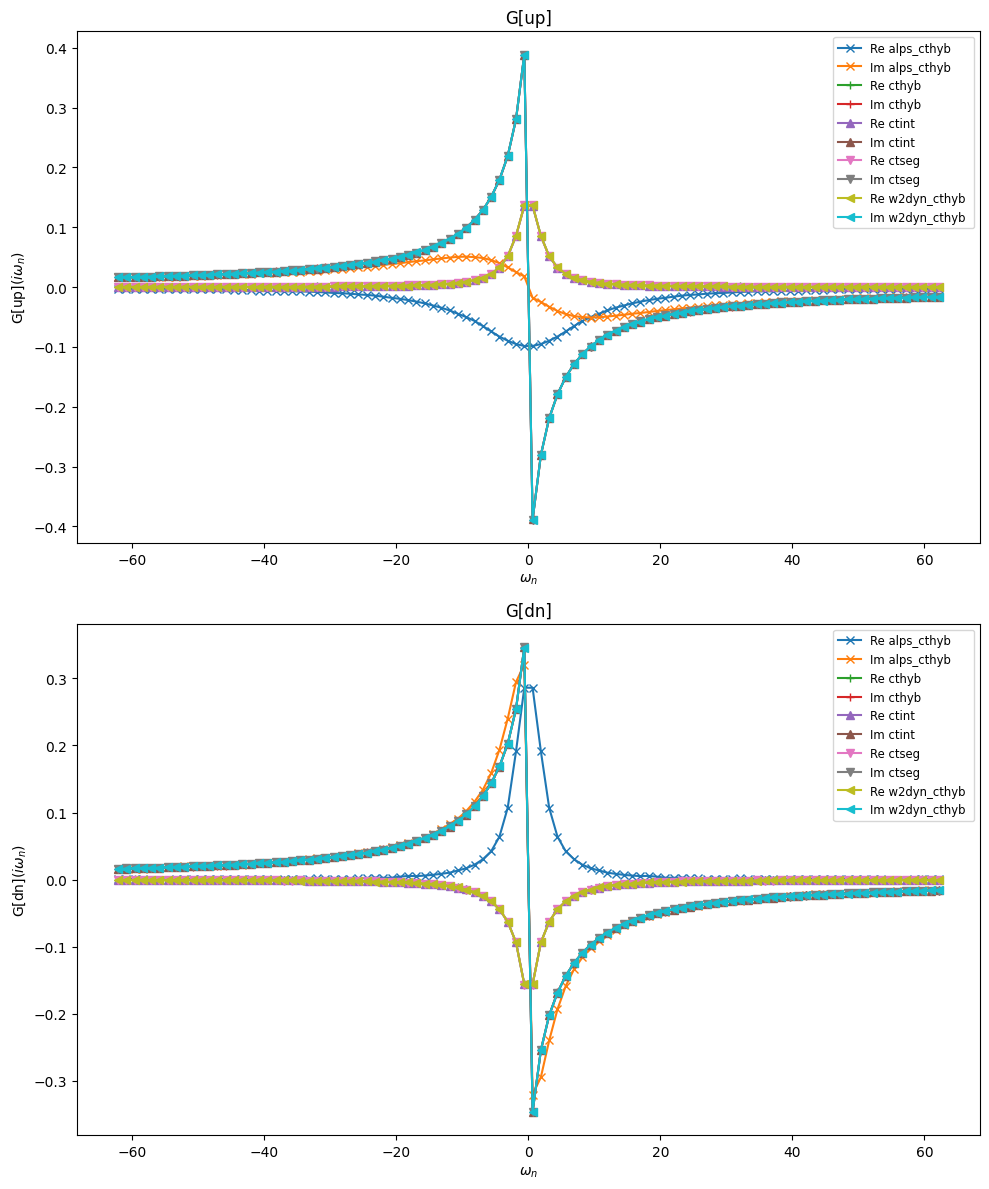

In [3]:
G_dict = {s: d['G'] for s, d in data.items() if 'G' in d}
if G_dict:
    plot_iw_comparison(G_dict, 'G', block_lst)
    deviation_table(G_dict, block_lst, label='G')

## 2. Self-Energy $\Sigma(i\omega_n)$


  Sigma max-norm deviations:
                  alps_cthyb        cthyb        ctint        ctseg  w2dyn_cthyb
     alps_cthyb                  1.21e+01     1.21e+01     1.27e+01     1.26e+01
          cthyb                               2.64e+00     2.94e+00     3.70e+00
          ctint                                            1.59e+00     1.47e+00
          ctseg                                                         2.13e+00
    w2dyn_cthyb                                                                 


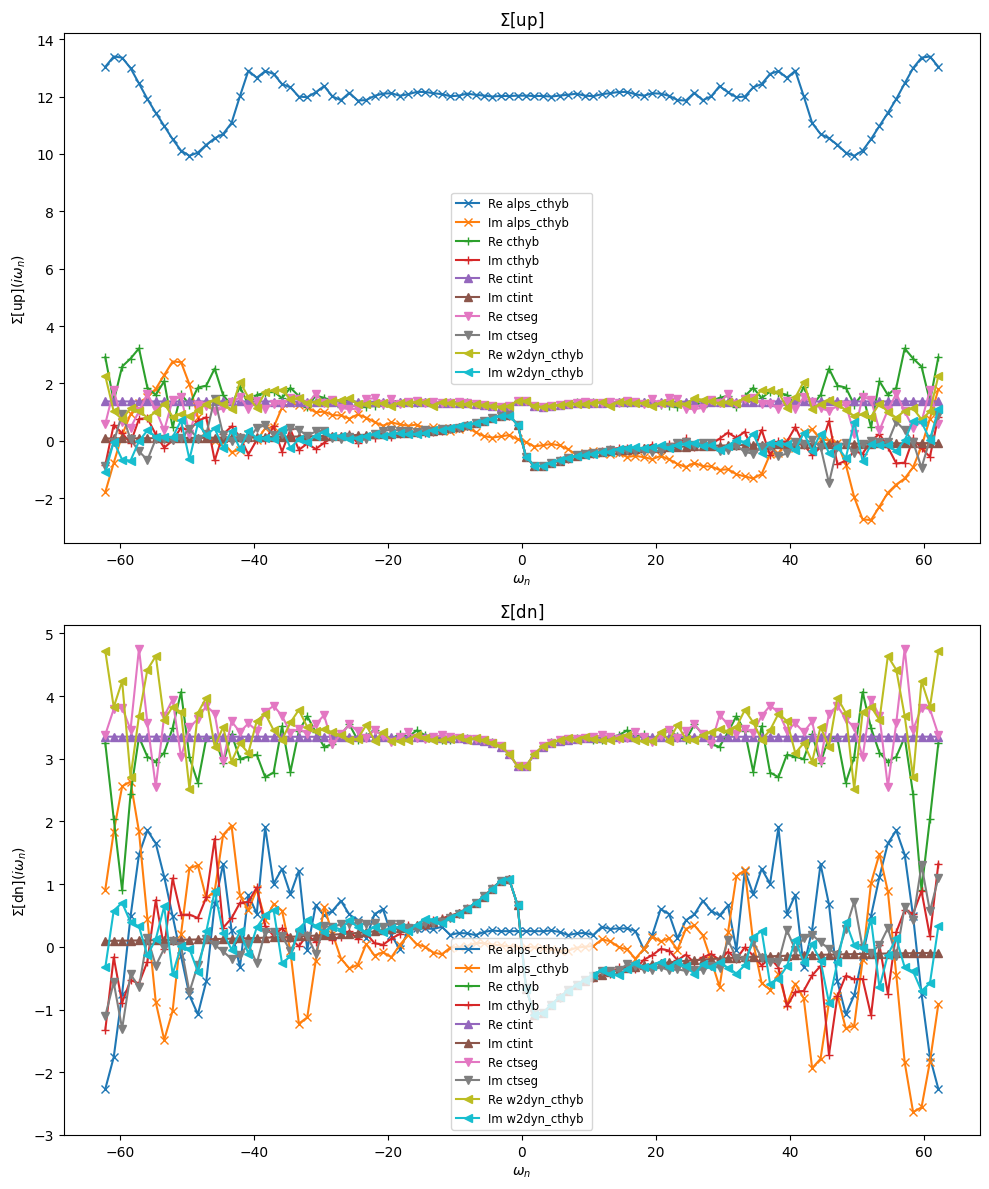

In [4]:
Sigma_dict = compute_sigma(data, G0_iw)
if Sigma_dict:
    plot_iw_comparison(Sigma_dict, r'$\Sigma$', block_lst)
    deviation_table(Sigma_dict, block_lst, label='Sigma')

## 3. Static Observables

In [5]:
plot_static_obs_table(data, 'density')
plot_static_obs_table(data, 'nn_ab')


  density:
    cthyb                 dn: 0.274309, up: 0.671008
    ctint                 dn: 0.274658, up: 0.670687
    ctseg                 dn: 0.274306, up: 0.671318
    nrg                   dn: 0.579580, up: 0.359530

  nn_ab:
    cthyb                 dn,dn: 0.274309, dn,up: 0.064992, up,dn: 0.064992, up,up: 0.671008


## 4. Real-Frequency Spectral Function $A(\omega)$

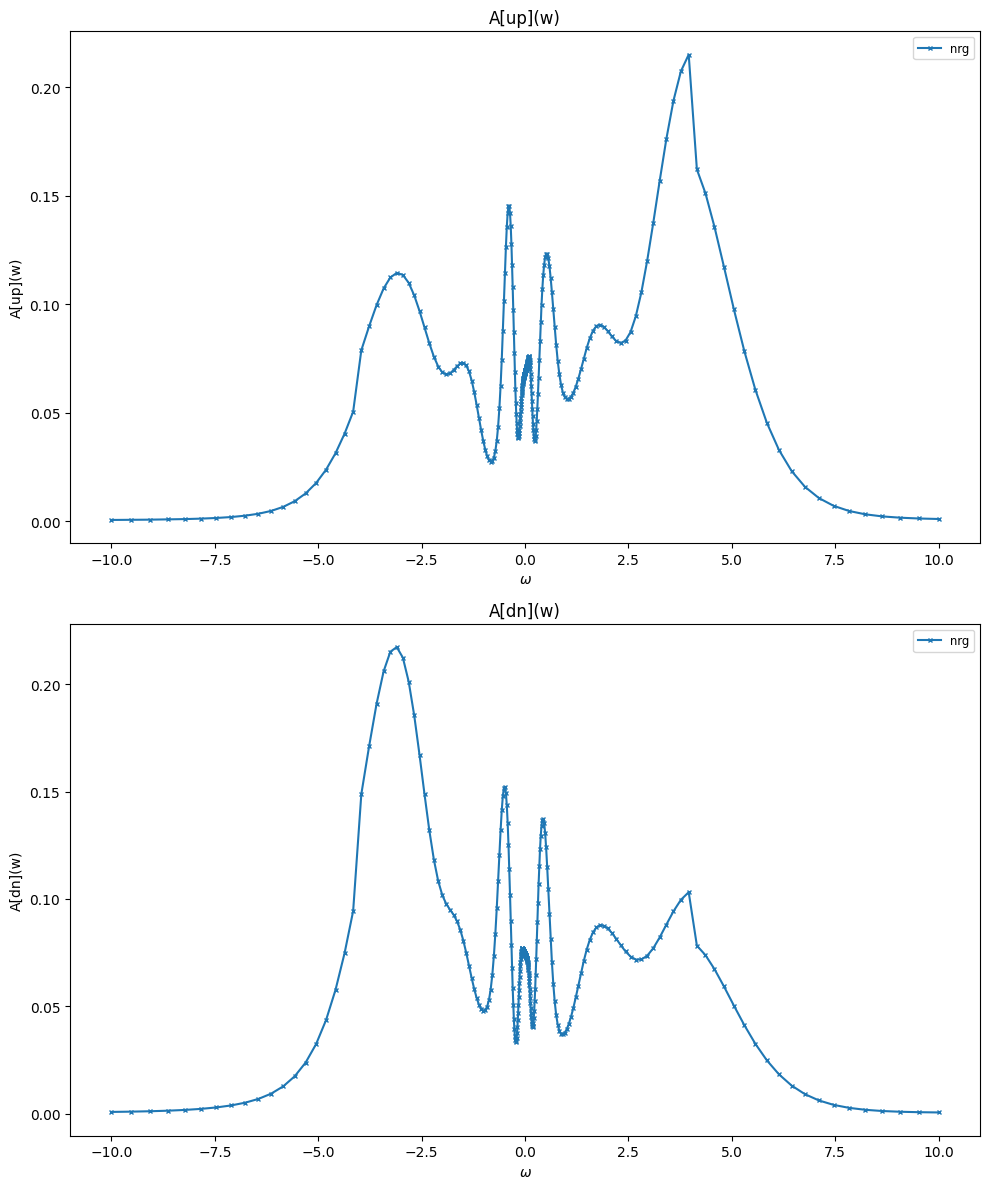

In [6]:
G_w_dict = {s: d['G_w'] for s, d in data.items() if 'G_w' in d}
if G_w_dict:
    plot_w_comparison(G_w_dict, 'G_w', block_lst, spectral=True)
else:
    print("No solver has real-frequency data.")

## 5. Three-Point Correlator $\chi_3$

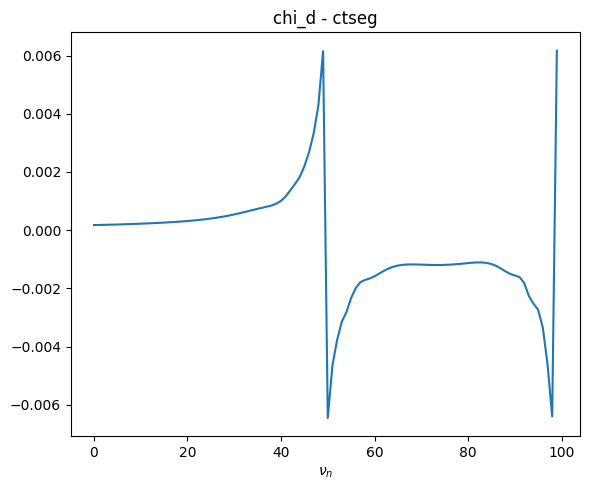

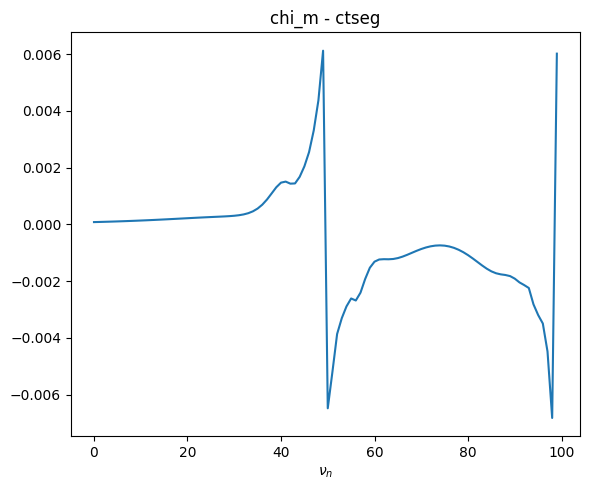

In [7]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi3_{ch}'
    chi3 = {s: d[key] for s, d in data.items() if key in d}
    if chi3:
        plot_chi_contour(chi3, ch)

## 6. Two-Particle Green Function $\chi_4$ / $G_{2c}$

In [8]:
for ch in ['d', 'm', 's', 't']:
    key = f'chi4_{ch}'
    chi4 = {s: d[key] for s, d in data.items() if key in d}
    if chi4:
        plot_chi_contour(chi4, ch)